In [4]:
# @title
import json
import time
import requests


# Get Demo API Key Here:
# https://developers.google.com/maps/demo-key
# API_KEY = "AIz...."


# Pass 1: Spatial Waypoints along Yonge St (~58 km)
YONGE_WAYPOINTS = [
    {"lat": 43.6525, "lng": -79.3817, "label": "Downtown / Queen"},
    {"lat": 43.6700, "lng": -79.3870, "label": "Bloor / Yorkville"},
    {"lat": 43.6880, "lng": -79.3940, "label": "St. Clair"},
    {"lat": 43.7080, "lng": -79.3985, "label": "Eglinton"},
    {"lat": 43.7250, "lng": -79.4020, "label": "Lawrence"},
    {"lat": 43.7440, "lng": -79.4060, "label": "York Mills"},
    {"lat": 43.7680, "lng": -79.4120, "label": "Sheppard"},
    {"lat": 43.7780, "lng": -79.4140, "label": "Finch"},
    {"lat": 43.8150, "lng": -79.4230, "label": "Steeles / Thornhill"},
    {"lat": 43.8550, "lng": -79.4320, "label": "Richmond Hill South"},
    {"lat": 43.8950, "lng": -79.4420, "label": "Richmond Hill North"},
    {"lat": 43.9450, "lng": -79.4520, "label": "Aurora South"},
    {"lat": 43.9850, "lng": -79.4600, "label": "Aurora North"},
    {"lat": 44.0100, "lng": -79.4640, "label": "Mulock / Yonge"},
    {"lat": 44.0300, "lng": -79.4680, "label": "Newmarket South"},
    {"lat": 44.0600, "lng": -79.4750, "label": "Newmarket / Davis Dr"},
]

# Pass 2: Targeted Chain/Brand Queries along Yonge St (stop chains where Matcha isn't a key word)
MATCH_CHAINS_YONGE = [
    "M Cha Bar Yonge Street",
    "Tsujiri Yonge Street",
    "TenRen Tea Yonge Street",
    "Macao Imperial Tea Yonge Street",
    "Bloom Cafe",
    "Coffee Lunar",
    "Another Land Coffee"
]

URL = "https://places.googleapis.com/v1/places:searchText"
HEADERS = {
    "Content-Type": "application/json",
    "X-Goog-Api-Key": API_KEY,
    "X-Goog-FieldMask": "places.id,places.displayName,places.formattedAddress,places.location,places.websiteUri,places.rating",
}

unique_places = {}


def process_places(places):
    for p in places:
        addr = p.get("formattedAddress", "")
        name = p.get("displayName", {}).get("text", "")
        pid = p.get("id")

        if ("Yonge" in addr or "Yonge" in name) and pid not in unique_places:
            unique_places[pid] = {
                "id": pid,
                "name": name,
                "address": addr,
                "lat": p.get("location", {}).get("latitude"),
                "lng": p.get("location", {}).get("longitude"),
                "rating": p.get("rating"),
                "website": p.get("websiteUri", ""),
            }


# Executing Pass 1 (Spatial Sweep) KEYWORD MATCHA
print("=== Pass 1: Running Spatial Sweep along Yonge Corridor ===")
for wp in YONGE_WAYPOINTS:
    print(f"Scanning near {wp['label']}...")
    payload = {
        "textQuery": "matcha",
        "locationBias": {
            "circle": {
                "center": {"latitude": wp["lat"], "longitude": wp["lng"]},
                "radius": 1200.0,
            }
        },
    }
    res = requests.post(URL, json=payload, headers=HEADERS)
    if res.status_code == 200:
        process_places(res.json().get("places", []))
    time.sleep(0.2)

# Executing Pass 2 (Specific Brand Sweep)
print("\n=== Pass 2: Running Targeted Chain Sweep ===")
for brand in MATCH_CHAINS_YONGE:
    print(f"Querying for '{brand}'...")
    payload = {"textQuery": brand}
    res = requests.post(URL, json=payload, headers=HEADERS)
    if res.status_code == 200:
        process_places(res.json().get("places", []))
    time.sleep(0.2)

results = list(unique_places.values())
with open("yonge_matcha_google.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(
    f"\nExtraction complete! Saved {len(results)} places to yonge_matcha_google.json"
)

=== Pass 1: Running Spatial Sweep along Yonge Corridor ===
Scanning near Downtown / Queen...
Scanning near Bloor / Yorkville...
Scanning near St. Clair...
Scanning near Eglinton...
Scanning near Lawrence...
Scanning near York Mills...
Scanning near Sheppard...
Scanning near Finch...
Scanning near Steeles / Thornhill...
Scanning near Richmond Hill South...
Scanning near Richmond Hill North...
Scanning near Aurora South...
Scanning near Aurora North...
Scanning near Mulock / Yonge...
Scanning near Newmarket South...
Scanning near Newmarket / Davis Dr...

=== Pass 2: Running Targeted Chain Sweep ===
Querying for 'M Cha Bar Yonge Street'...
Querying for 'Tsujiri Yonge Street'...
Querying for 'TenRen Tea Yonge Street'...
Querying for 'Macao Imperial Tea Yonge Street'...
Querying for 'Bloom Cafe'...
Querying for 'Coffee Lunar'...
Querying for 'Another Land Coffee'...

Extraction complete! Saved 35 places to yonge_matcha_google.json


In [17]:
pip install gpxpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.7 MB/s eta 0:00:00


In [23]:
import json
import folium
import gpxpy

################################# 1. Define Yonge Street Waypoints #############
YONGE_WAYPOINTS = [
    {"lat": 43.641911050583474, "lng": -79.37476433235993, "label": "Downtown / Queen"},
    {"lat": 43.652417099071094, "lng": -79.37923096844979, "label": "Downtown / Queen"},
    {"lat": 43.67021230989809, "lng": -79.38674620425917, "label": "Yorkville / Bloor"},
    {"lat": 43.68809606407452, "lng": -79.39414474791617, "label": "Midtown / St. Clair"},
    {"lat": 43.70676534649821, "lng": -79.39835466396873, "label": "Midtown / Eglinton"},
    {"lat": 43.72506145718989, "lng": -79.40224234597584, "label": "Old Toronto / Lawrence"},
    {"lat": 43.74410462198868, "lng": -79.40673479002835, "label": "North York / York Mills"},
    {"lat": 43.76147413613703, "lng": -79.41102203051082, "label": "North York / Sheppard"},
    {"lat": 43.77983069709839, "lng": -79.41561940607356, "label": "North York / Finch"},
    {"lat": 43.79813124908243, "lng": -79.42008071701599, "label": "Thornhill / Steeles"},
    {"lat": 43.853055460797734, "lng": -79.43311958633262, "label": "Richmond Hill / 16th Avenue"},
    {"lat": 43.8712473399109, "lng": -79.4373655458498, "label": "Richmond Hill / Major Mackenzie"},
    {"lat": 43.90791533038886, "lng": -79.44582407653124, "label": "Richmond Hill / Gamble"},
    {"lat": 43.96307531843303, "lng": -79.45871548633053, "label": "Richmond Hill / Bloomington"},
    {"lat": 43.99973184827545, "lng": -79.46762237468256, "label": "Aurora / Wellington"},
    {"lat": 44.01803207108951, "lng": -79.47193126118803, "label": "Aurora / St John Sideroad"},
    {"lat": 44.03629313960371, "lng": -79.47612757283505, "label": "Newmarket / Mulock"},
    {"lat": 44.05482888712313, "lng": -79.4804695305051, "label": "Newmarket / Davis Dr"},
    {"lat": 44.12822025972357, "lng": -79.49635979229458, "label": "Queensville Sideroad"},
    {"lat": 44.1433484094235, "lng": -79.50242642314915, "label": "End of Yonge Street"},
]

##############################################################################

# Load JSON dataset ##################################################
# This is an unfiltered JSON Dataset, so might get sushi places that contain matcha..
#############################################################################

try:
    with open("yonge_matcha_google.json", "r", encoding="utf-8") as f:
        data = json.load(f)
except FileNotFoundError:
    data = []

# 2. Initialize map
m = folium.Map(
    location=[43.7000, -79.4000],
    zoom_start=11,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Source: Esri, DeLorme, NAVTEQ, USGS, Intermap, iPC, NRCAN, Esri Japan, METI, Esri China (Hong Kong), Esri (Thailand), TomTom, 2012"
)

####### 3. Add Yonge Waypoints line and markers, Rough Wavepoints #############
waypoint_coords = [[wp["lat"], wp["lng"]] for wp in YONGE_WAYPOINTS]

# Draw route line
folium.PolyLine(
    locations=waypoint_coords,
    color="#2b5c8f",
    weight=4,
    opacity=0.8,
    tooltip="Planned Yonge Street Route",
).add_to(m)

# Add waypoint dots
for wp in YONGE_WAYPOINTS:
    folium.CircleMarker(
        location=[wp["lat"], wp["lng"]],
        radius=4,
        color="#2b5c8f",
        fill=True,
        fill_color="#ffffff",
        fill_opacity=1.0,
        popup=wp["label"],
        tooltip=wp["label"],
    ).add_to(m)

# 4. Add Matcha locations
for spot in data:
    website_html = (
        f'<a href="{spot["website"]}" target="_blank">Visit Website</a>'
        if spot.get("website")
        else "No website"
    )
    rating_str = f"⭐ {spot['rating']} / 5.0" if spot.get("rating") else ""

    popup_content = f"""
    <div style="font-family: sans-serif; width: 200px;">
        <h4 style="margin: 0 0 5px 0; color: #1b4332;">{spot['name']}</h4>
        <p style="margin: 0 0 5px 0; font-size: 12px;">{spot['address']}</p>
        <p style="margin: 0 0 5px 0; font-size: 12px; font-weight: bold;">{rating_str}</p>
        <p style="margin: 0; font-size: 12px;">{website_html}</p>
    </div>
    """

    folium.Marker(
        location=[spot["lat"], spot["lng"]],
        popup=folium.Popup(popup_content, max_width=250),
        tooltip=spot["name"],
        icon=folium.Icon(color="green", icon="coffee", prefix="fa"),
    ).add_to(m)

# 5. Auto-fit bounds
all_coords = waypoint_coords + [[spot["lat"], spot["lng"]] for spot in data]
if all_coords:
    m.fit_bounds(all_coords)


# 1. Parse the GPX file
gpx_filename = "StravaData.gpx"

with open(gpx_filename, "r") as f:
    gpx = gpxpy.parse(f)

# 2. Extract telemetry per point
latlngs = []
elevations = []
distances_km = [0.0]
cumulative_dist = 0.0

prev_point = None
for track in gpx.tracks:
    for segment in track.segments:
        for point in segment.points:
            latlngs.append((point.latitude, point.longitude))
            elevations.append(point.elevation if point.elevation else 0)

            if prev_point is not None:
                dist_step = point.distance_2d(prev_point) or 0.0
                cumulative_dist += dist_step / 1000.0
                distances_km.append(cumulative_dist)

            prev_point = point

# 5. Add to Current Map
folium.PolyLine(
    locations=latlngs,
    color="#FFA500",
    weight=5,
    opacity=0.85,
    tooltip="Strava 58 km Route",
).add_to(m)

##


# Save & render map
m.save("yonge_matcha_map.html")
m

https://www.strava.com/activities/19857939096/overview?utm_medium=web_embed&utm_source=activity_embed&strava_deeplink_url=strava%3A%2F%2Factivities%2F19857939096

=== GPX Telemetry Summary ===
Total Distance: 59.28 km
Total Elevation Gain: 703.5 m
Total Elevation Loss: 815.7 m
Min Elevation: 108.8 m | Max Elevation: 319.6 m


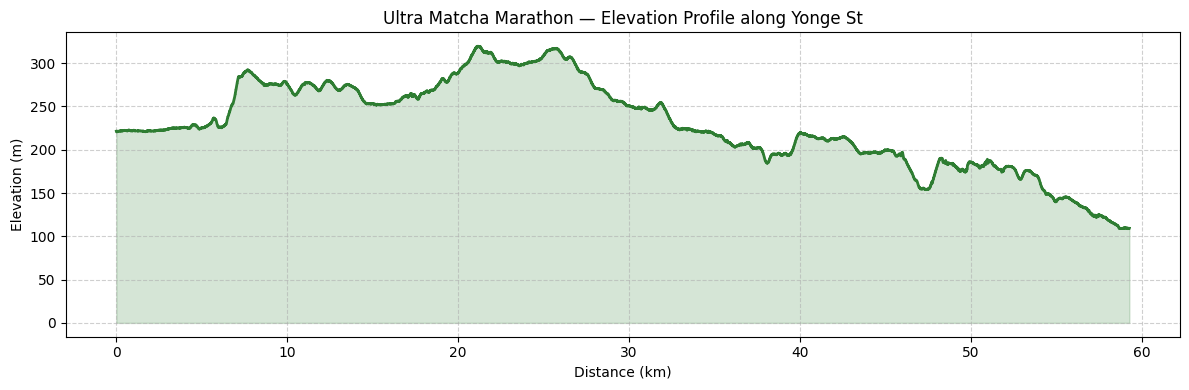

In [24]:
!pip install gpxpy folium matplotlib

import folium
import gpxpy
import matplotlib.pyplot as plt

# 1. Parse the GPX file
gpx_filename = "StravaData.gpx"

with open(gpx_filename, "r") as f:
    gpx = gpxpy.parse(f)

# 2. Extract telemetry per point
latlngs = []
elevations = []
distances_km = [0.0]
cumulative_dist = 0.0

prev_point = None
for track in gpx.tracks:
    for segment in track.segments:
        for point in segment.points:
            latlngs.append((point.latitude, point.longitude))
            elevations.append(point.elevation if point.elevation else 0)

            if prev_point is not None:
                dist_step = point.distance_2d(prev_point) or 0.0
                cumulative_dist += dist_step / 1000.0
                distances_km.append(cumulative_dist)

            prev_point = point

# 3. Print Key Elevation & Distance Metrics
total_distance = gpx.length_2d() / 1000.0
uphill, downhill = gpx.get_uphill_downhill()

print(f"=== GPX Telemetry Summary ===")
print(f"Total Distance: {total_distance:.2f} km")
print(f"Total Elevation Gain: {uphill:.1f} m")
print(f"Total Elevation Loss: {downhill:.1f} m")
print(f"Min Elevation: {min(elevations):.1f} m | Max Elevation: {max(elevations):.1f} m")
print("=" * 30)

# 4. Plot Elevation Profile Chart
plt.figure(figsize=(12, 4))
plt.plot(distances_km, elevations, color="#2e7d32", linewidth=2)
plt.fill_between(distances_km, elevations, alpha=0.2, color="#2e7d32")
plt.title("Ultra Matcha Marathon — Elevation Profile along Yonge St")
plt.xlabel("Distance (km)")
plt.ylabel("Elevation (m)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

